# Legal NLP Model Evaluation: DeepSeek-R1-Distill-Qwen-7B vs. Claude Ground Truth
This notebook evaluates the performance of the DeepSeek-R1-Distill-Qwen-7B extraction model against ground truth data (Claude). It calculates Exact Match Accuracy, Token F1 Scores, ROUGE Scores, and BERTScore for various legal document fields.

In [1]:
# Install required libraries (uncomment if running for the first time)
# !pip install pandas rouge-score bert-score scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from bert_score import score
import warnings

warnings.filterwarnings('ignore')

# Set a beautiful, professional theme for all visualizations
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 8)

/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Data Loading & Preprocessing
Loading the ground truth and prediction datasets, standardizing column names, and merging them on `case_id`.

In [2]:
# Load Datasets
# Ground truth (Claude-generated)
claude = pd.read_excel("enriched_legal_records.xlsx")

# Model predictions (DeepSeek-R1-Distill-Qwen-7B)
deepseek = pd.read_excel("indilex_extracted_output_DeepSeek.xlsx")

# Standardize Claude columns to match model output
claude = claude.rename(columns={
    "CASE ID": "case_id",
    "LANGUAGE": "language",
    "CASE TYPE": "case_type",
    "JUDGMENT TEXT": "judgment_text",
    "SUBJECT": "subject",
    "OBJECT": "object",
    "OBJECTIVE ASPECT": "objective_aspect",
    "SUBJECTIVE ASPECT": "subjective_aspect",
    "LEGAL PROVISIONS": "legal_provisions",
    "REASONING": "reasoning"
})

# Merge datasets
df = pd.merge(claude, deepseek, on="case_id", suffixes=("_gt", "_pred"))
print(f"Ground truth rows: {len(claude)}")
print(f"DeepSeek prediction rows: {len(deepseek)}")
print(f"Merged (matched) rows: {len(df)}")

# Check for missing reasoning (DeepSeek may have empty reasoning)
reasoning_missing = df["reasoning_pred"].isna().sum()
if reasoning_missing > 0:
    print(f"WARNING: {reasoning_missing} rows have missing reasoning_pred — filling with empty string")
    df["reasoning_pred"] = df["reasoning_pred"].fillna("")

# Fill any other NaN fields to avoid errors
for col in df.columns:
    if col.endswith("_gt") or col.endswith("_pred"):
        df[col] = df[col].fillna("Unknown")

df.head()

Ground truth rows: 4
DeepSeek prediction rows: 4
Merged (matched) rows: 4


,case_id,language_gt,case_type_gt,judgment_text_gt,subject_gt,object_gt,objective_aspect_gt,subjective_aspect_gt,legal_provisions,reasoning_gt,...,case_type_pred,subject_pred,object_pred,objective_aspect_pred,subjective_aspect_pred,reasoning_pred,raw_output,parse_ok,attempts,error
0,ALL_CRIM_000001,Hindi,Criminal,Application U/S 482 CrPC No. 741 of 2024. Appl...,Dinesh Yadav @ Dinesh Kumar And 7 Others,Wife/Complainant,Assault; Bigamy; Cruelty; Intentional Insult; ...,Dowry Demand,• CrPC Section 482\n• IPC Section 323\n• IPC S...,The legal issue before the court was whether c...,...,Criminal,Criminal,Administrative Authority,Criminal defamation under section 482 of the C...,Defamation of reputation and seeking an order ...,The court found that the statements made by th...,"Alright, I need to extract legal information f...",True,1,NaN
1,ALL_CRIM_000002,Hindi,Criminal,Criminal Misc. Anticipatory Bail Application U...,Kamlesh Jaiswal Alias Monu Jaiswal And Another,State/Society,Criminal Law Amendment Act Offence,Not Clearly Specified,• CrPC Section 438\n• IPC Section 302\n• IPC S...,The legal issue was whether anticipatory bail ...,...,Criminal,Criminal,Civil,Anticipatory bail application under Section 43...,Claimed that anticipatory bail was granted wit...,The court found that the anticipatory bail was...,"Alright, I need to extract legal information f...",True,1,NaN
2,ALL_CRIM_000003,Hindi,Criminal,Application U/S 482 CrPC No. 51 of 2024. Appli...,Bahal Khan And 4 Others,Complainant/Informant,Rioting; Rioting With Deadly Weapon; Assault; ...,Intent/Knowledge To Cause Death Or Serious Harm,• CrPC Section 482\n• IPC Section 147\n• IPC S...,The legal issue was whether an FIR and consequ...,...,Criminal,Criminal,State,Dismissal of application based on FIRs,Grounds for dismissal based on pending FIRs,The court dismissed the application as FIRs ar...,"Alright, I need to extract legal information f...",True,1,NaN
3,ALL_CRIM_000004,Hindi,Criminal,Application U/S 482 CrPC No. 12742 of 2023. Ap...,Banshi Lal,Complainant/Informant,Kidnapping Or Abduction,Intent To Compel Wrongful Restraint/Confinement,• CrPC Section 164\n• CrPC Section 482\n• IPC ...,The legal issue was whether orders accepting t...,...,Criminal,"State of U.P. Theu, Prin, Secy: Home Lko. And ...",Banshi Lal,Criminal Defamation,To withdraw the complaint and quash the public...,The court found that the complainant's allegat...,"Alright, I need to extract legal information f...",True,1,NaN


## 2. Exact Match Evaluation
Calculating how often the model's extraction perfectly matches the ground truth (case insensitive and stripped of whitespace).

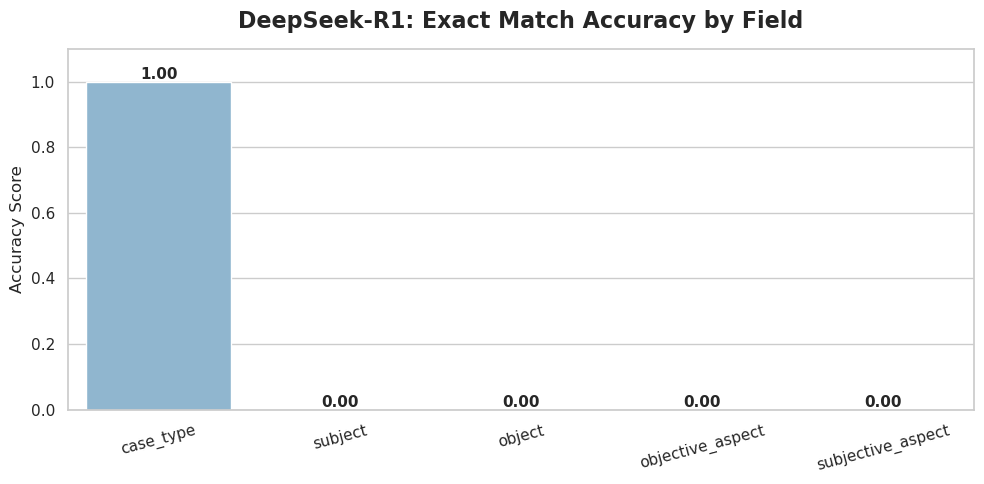

In [3]:
fields_em = ["case_type", "subject", "object", "objective_aspect", "subjective_aspect"]
em_scores = {}

for field in fields_em:
    acc = (
        df[f"{field}_gt"].astype(str).str.lower().str.strip() 
        == 
        df[f"{field}_pred"].astype(str).str.lower().str.strip()
    ).mean()
    em_scores[field] = acc

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(em_scores.keys()), y=list(em_scores.values()), palette="Blues_d")
plt.title("DeepSeek-R1: Exact Match Accuracy by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.1)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Token F1 Score Evaluation
Exact match is often too strict. Token F1 measures the overlap of individual words between the prediction and ground truth.

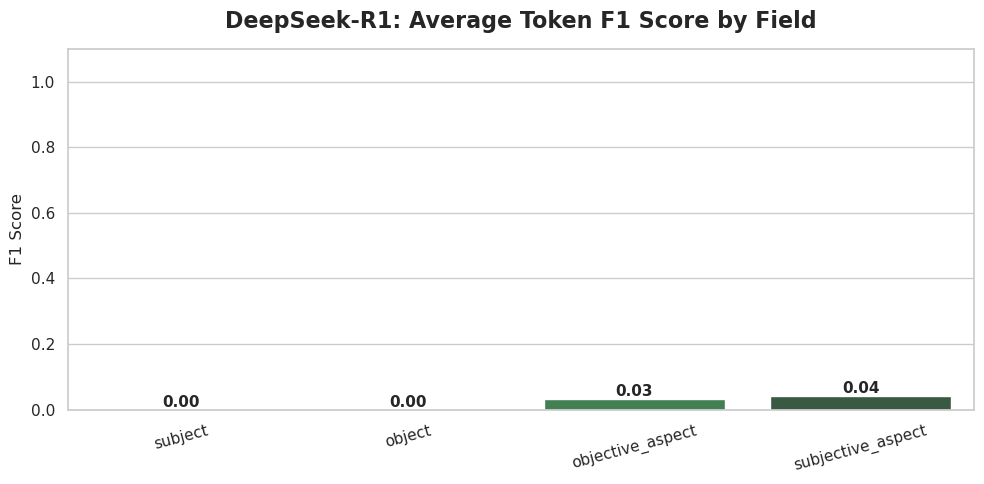

In [4]:
def token_f1(gt, pred):
    gt_tokens = set(str(gt).lower().split())
    pred_tokens = set(str(pred).lower().split())
    
    tp = len(gt_tokens.intersection(pred_tokens))
    precision = tp / max(len(pred_tokens), 1)
    recall = tp / max(len(gt_tokens), 1)
    
    if precision + recall == 0:
        return 0
    return (2 * precision * recall) / (precision + recall)

fields_f1 = ["subject", "object", "objective_aspect", "subjective_aspect"]
f1_scores = {}

for field in fields_f1:
    scores = [token_f1(row[f"{field}_gt"], row[f"{field}_pred"]) for _, row in df.iterrows()]
    f1_scores[field] = np.mean(scores)

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="Greens_d")
plt.title("DeepSeek-R1: Average Token F1 Score by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. NLP Generation Metrics (Reasoning)
Evaluating the long-form "reasoning" field using ROUGE (n-gram overlap) and BERTScore (semantic similarity).

ROUGE computed on 4 reasoning pairs


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


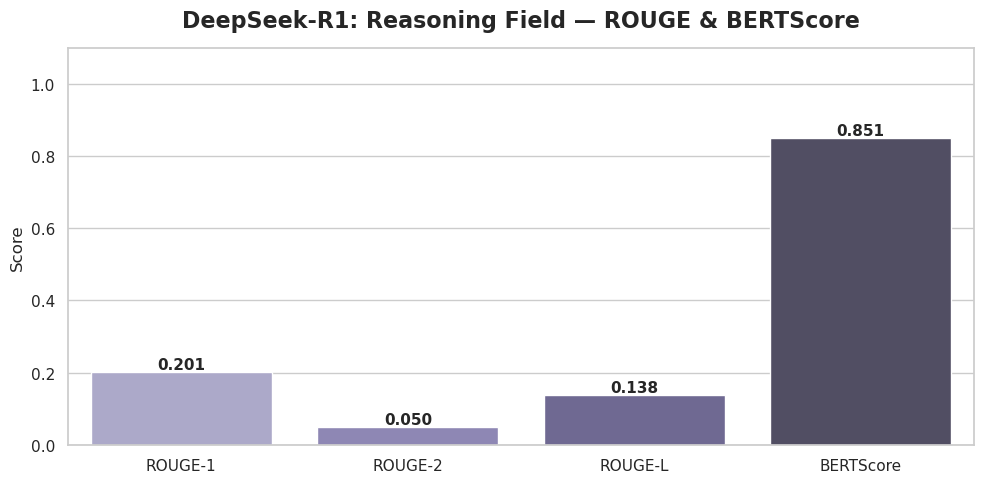

In [5]:
# 1. ROUGE Scores
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []

for _, row in df.iterrows():
    gt = str(row["reasoning_gt"]).strip()
    pred = str(row["reasoning_pred"]).strip()
    # Skip rows where both are empty/Unknown — they'd give misleading scores
    if gt in ("", "nan", "Unknown") and pred in ("", "nan", "Unknown"):
        continue
    if gt in ("", "nan", "Unknown"):
        gt = "No reasoning provided."
    if pred in ("", "nan", "Unknown"):
        pred = "No reasoning provided."
    score_dict = scorer.score(gt, pred)
    r1.append(score_dict["rouge1"].fmeasure)
    r2.append(score_dict["rouge2"].fmeasure)
    rl.append(score_dict["rougeL"].fmeasure)

rouge_results = {
    "ROUGE-1": np.mean(r1) if r1 else 0.0,
    "ROUGE-2": np.mean(r2) if r2 else 0.0,
    "ROUGE-L": np.mean(rl) if rl else 0.0
}
print(f"ROUGE computed on {len(r1)} reasoning pairs")

# 2. BERTScore
predictions = df["reasoning_pred"].astype(str).tolist()
references = df["reasoning_gt"].astype(str).tolist()

P, R, F1 = score(predictions, references, lang="en", verbose=False)
bert_score_val = F1.mean().item()

# Combine metrics for visualization
generation_metrics = {**rouge_results, "BERTScore": bert_score_val}

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(generation_metrics.keys()), y=list(generation_metrics.values()), palette="Purples_d")
plt.title("DeepSeek-R1: Reasoning Field — ROUGE & BERTScore", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Final Evaluation Summary
A consolidated view of the generation metrics.

In [6]:
# Display as a beautifully formatted Pandas DataFrame
final_results_df = pd.DataFrame([generation_metrics])
final_results_df.index = ["DeepSeek-R1-Distill-Qwen-7B"]

# Style the dataframe output
final_results_df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'white',
    'font-size': '11pt'
}).format("{:.4f}")

,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
DeepSeek-R1-Distill-Qwen-7B,0.2008,0.0496,0.1382,0.8513
